<font size=3;>
<p style="text-align: right;"> Lab Solution --- <b>NOT FOR DISTRIBUTION!</b> </p>
</font>

# Lab G1: Two-Sample t Hypothesis Test

## Setup

In [1]:
# Import some useful functions
from numpy import *
from numpy.random import *
from datascience import *
from statsmodels.formula.api import *

# Define some useful functions
def correlation(array_1, array_2):
    return corrcoef(array_1, array_2).item(1)

# Customize look of graphics
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 60
%matplotlib inline

# Force display of all values 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Hide some unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")
import numpy
numpy.int = numpy.int_

## Precision Manufacturing Quality

### Business Decision

A manufacturing organization uses 2 special 3D printers to produce precision parts, specificallly 10cm-diameter tubes.  Recently, the machine operators have become suspicious that the first machine produces tubes on average slightly larger than the second machine on average does.  If so, that would necessitate expensive action to get the machines aligned.

Assume that you are the Vice President of Manufacturing.  Does the second machine produce on average tubes of smaller diameter than the first machine does?  Should you invest in aligning the machines?

### Data

Machine #1 produces a sample of 12 tubes with these diameters:  
10.03, 10.04, 10.02, 9.98, 9.99, 10.04, 10.01, 10.04, 10.05, 9.95, 9.96, 9.99

Show the sample size, sample mean, sample standard deviation, and
a histogram of the sample diameters (10 bins, range 9.95 to 10.1).

12

10.008333333333335

0.033799766898962871

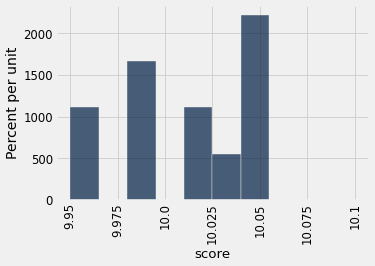

In [2]:
sample_1 = Table().with_column('score', make_array(10.03, 10.04, 10.02, 9.98, 9.99, 10.04,
                                                   10.01, 10.04, 10.05, 9.95, 9.96, 9.99))

sample_size_1 = sample_1.num_rows
sample_mean_1 = mean(sample_1.column('score'))
sample_std_1  = std(sample_1.column('score'), ddof=1)

sample_size_1
sample_mean_1
sample_std_1
sample_1.hist(bins=10, range=make_array(9.95,10.1))

Machine #2 produces a sample of 12 tubes with these diameters:  
10.03, 9.75, 10.01, 9.75, 9.99, 10.01, 10.01, 10.08, 10.08, 9.95, 9.96, 9.99

Show the sample size, sample mean, sample standard deviation, and a histogram of the sample diameters (10 bins, range 9.95 to 10.1).

12

9.9674999999999994

0.10897247358851682

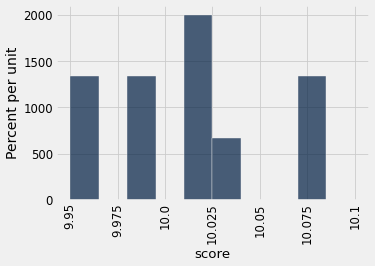

In [3]:
sample_2 = Table().with_column('score', make_array(10.03, 9.75, 10.01, 9.75, 9.99, 10.01,
                                                   10.01, 10.08, 10.08, 9.95, 9.96, 9.99))

sample_size_2 = sample_2.num_rows
sample_mean_2 = mean(sample_2.column('score'))
sample_std_2  = std(sample_2.column('score'), ddof=1)

sample_size_2
sample_mean_2
sample_std_2
sample_2.hist(bins=10, range=make_array(9.95,10.1))

### Analysis

Hypothesize that the difference between population means (pop_mean_1 - pop_mean_2) is $\leq$ 0.
The alternative to this hypothesis is that the difference between population means is $\gt$ 0.

In [4]:
pop_mean_diff_hypo = 0
pop_mean_diff_hypo

0

Calculate and show the two-sample t @ hypothesized population means difference 0.

$$
\textit{two-sample t} = \cfrac{(\textit{sample mean}_1 - \textit{sample mean}_2) - \textit{pop mean diff hypo}}
                              {\sqrt{\cfrac{{\textit{sample std}_1}^2}{\textit{sample size}_1} +
                                     \cfrac{{\textit{sample std}_2}^2}{\textit{sample size}_2}}}
$$

In [5]:
two_sample_t = ( (sample_mean_1 - sample_mean_2) - pop_mean_diff_hypo) / \
                 sqrt( (sample_std_1**2 / sample_size_1) + (sample_std_2**2 / sample_size_2) )
two_sample_t

1.2397751512485682

Calculate and show the degrees of freedom for two samples.  This number will be used to choose a specific standard t distribution.

$$
\textit{df} =
\cfrac{\left(\cfrac{{\textit{sample std}_1}^2}{\textit{sample size}_1} + \cfrac{{\textit{sample std}_2}^2}{\textit{sample size}_2}\right)^2}
{\left(\left(\cfrac{1}{\textit{sample size}_1-1}\right) \times \left(\cfrac{{\textit{sample std}_1}^2}{\textit{sample size}_1}\right) ^2 \right)    +
\left(\left(\cfrac{1}{\textit{sample size}_2-1}\right) \times \left(\cfrac{{\textit{sample std}_2}^2}{\textit{sample size}_2}\right) ^2 \right)}$$

Note, if the sample standard deviations are the same, then you can use a simpler formula for degrees of freedom.

$$
\textit{df} = (\textit{sample size}_1 - 1) + (\textit{sample size}_2 - 1)
$$

In [6]:
df = ((sample_std_1**2 / sample_size_1) + (sample_std_2**2 / sample_size_2))**2 / \
     ((1/(sample_size_1-1))*(sample_std_1**2/sample_size_1)**2 + (1/(sample_size_2-1))*(sample_std_2**2/sample_size_2)**2)
df

13.097082233214643

Get 1,000,000 values from the standard t distribution for the appropriate degrees of freedom.

Show a few of the values and a histogram of all the values (50 bins, range -4 to 4).

t
0.461574
0.0403342
-2.41828
0.945234
-0.343923
0.777448
-1.32693
-0.280686
-2.19178
0.1444


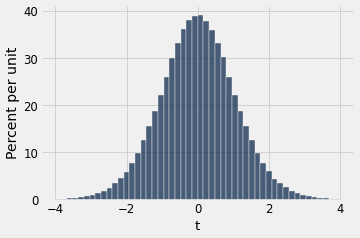

In [7]:
dist_array = standard_t(df, 1000000)
dist = Table().with_column('t', dist_array)

dist
dist.hist(bins=50, range=make_array(-4,4))

Calculate and show the probability that the two-sample t $\ge$ 1.2398 when the difference
in population means is $\le$ 0 (this is the p-value).
Also show the two-sample t and histogram of standard t distribution with the area
corresponding to the probability highlighted.

1.2397751512485682

0.118768

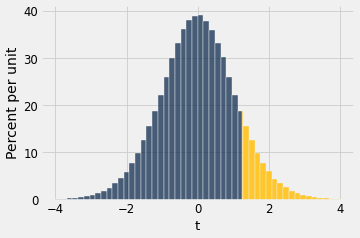

In [8]:
p_value = dist.where('t', are.above_or_equal_to(two_sample_t)).num_rows / dist.num_rows

two_sample_t
p_value
dist.hist(bins=50, range=make_array(-4,4), left_end=two_sample_t, right_end=4)

Calculate and show the critical value at significance level 0.05.
Note that the suspected difference between population means is ABOVE the hypothesized difference between
population means (0).
Also show the significance level and histogram of standard t distribution with the area corresponding
to the significance level highlighted.

0.05

1.7727987708874997

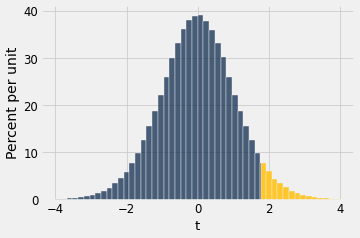

In [9]:
sig_level = 0.05
cv = percentile((1-sig_level)*100, dist.column('t'))

sig_level
cv
dist.hist(bins=50, range=make_array(-4,4), left_end=cv, right_end=4)

Calculate and show that you should assume the hypothesis is correct (difference in population means is $\le$ 0),
at significance level 0.05.

In [10]:
p_value > sig_level
two_sample_t < cv

True

True

<p style="text-align:left; font-size:10px;">
Copyright (c) Huntsinger Associates, LLC
<span style="float:right;">
Document revised October 5, 2023
</span>
</p>